In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

In [2]:
Main.include("FF.jl")
Main.include("LIKEn.jl")
Main.include("QCDNUM setting.jl")
Main.include("test.jl")

  +---------------------------------------------------------------------+   
  |                                                                     |   
  |    If you use QCDNUM, please refer to:                              |   
  |                                                                     |   
  |    M. Botje, Comput. Phys. Commun. 182(2011)490, arXiV:1005.1481    |   
  |                                                                     |   
  +---------------------------------------------------------------------+   
  

 FILLWT: start fragmentation weight calculations
 Subgrids    1 Subgrid points  100
 Pij LO
 Pij NLO
 Aij LO
 Aij NLO
 FILLWT: weight calculations completed

  
  
  +---------------------------------------------------------------------+   
  |                                                                     |   
  |    If you use QCDNUM, please refer to:                              |   
  |                                                           

0.0

In [3]:
Q = 10.0
z_array = np.linspace(0.01,1.0,100)

s_array = []
d_array = []
u_array = []
g_array = []
ub_array = []
db_array = []
sb_array = []

for z in z_array:
    s_array.append(z*Main.FF_func(z=z, μ=Q, flavor="s"))
    d_array.append(z*Main.FF_func(z=z, μ=Q, flavor="d"))
    u_array.append(z*Main.FF_func(z=z, μ=Q, flavor="u"))
    g_array.append(z*Main.FF_func(z=z, μ=Q, flavor="g")/5)
    ub_array.append(z*Main.FF_func(z=z, μ=Q, flavor="ub"))               
    db_array.append(z*Main.FF_func(z=z, μ=Q, flavor="db"))
    sb_array.append(z*Main.FF_func(z=z, μ=Q, flavor="sb"))
    

In [4]:
display(g_array)

[np.float64(0.38313794664249257),
 np.float64(0.37216883181244886),
 np.float64(0.3384913652628631),
 np.float64(0.30805416262120316),
 np.float64(0.2816148147267439),
 np.float64(0.25829838298642654),
 np.float64(0.2373756220499228),
 np.float64(0.2183547663258632),
 np.float64(0.20109492243623023),
 np.float64(0.18540521635365556),
 np.float64(0.17118633945664058),
 np.float64(0.15834531698940907),
 np.float64(0.1468095110292436),
 np.float64(0.13645385812274166),
 np.float64(0.12712909835263536),
 np.float64(0.1186764770165865),
 np.float64(0.11112151189634653),
 np.float64(0.10426063203245917),
 np.float64(0.09792586147708753),
 np.float64(0.09224007425898284),
 np.float64(0.08687723749630147),
 np.float64(0.08198575326067228),
 np.float64(0.07732649620626161),
 np.float64(0.0730092764866079),
 np.float64(0.0688683198039598),
 np.float64(0.06496919159506434),
 np.float64(0.06122774664181853),
 np.float64(0.05764852908816578),
 np.float64(0.05422536069855475),
 np.float64(0.05091825

In [5]:
df = pd.read_csv("Fortran Benchmark/10GeV.csv", delim_whitespace=True)
z_array_fortran = df["Z"]
s_array_fortran = df["S"]
d_array_fortran = df["D"]
u_array_fortran = df["U"]
g_array_fortran = df["GL"]/5
ub_array_fortran = df["UB"]
db_array_fortran = df["DB"]
sb_array_fortran = df["SB"]

/tmp/ipykernel_32245/614636697.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("Fortran Benchmark/10GeV.csv", delim_whitespace=True)


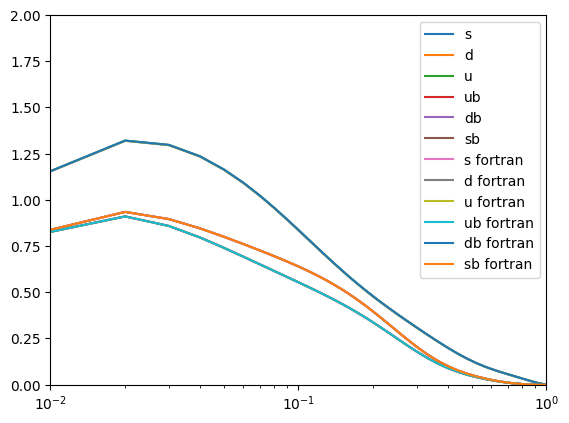

In [ ]:
plt.plot(z_array, s_array, label="s")
plt.plot(z_array, d_array, label="d")
plt.plot(z_array, u_array, label="u")
plt.plot(z_array, g_array, label="g/5")
plt.plot(z_array, ub_array, label="ub")
plt.plot(z_array, db_array, label="db")
plt.plot(z_array, sb_array, label="sb")

plt.plot(z_array_fortran, s_array_fortran, label="s fortran")
plt.plot(z_array_fortran, d_array_fortran, label="d fortran")
plt.plot(z_array_fortran, u_array_fortran, label="u fortran")
plt.plot(z_array_fortran, g_array_fortran, label="g/5 fortran")
plt.plot(z_array_fortran, ub_array_fortran, label="ub fortran")
plt.plot(z_array_fortran, db_array_fortran, label="db fortran")
plt.plot(z_array_fortran, sb_array_fortran, label="sb fortran")

plt.xscale("log")
plt.ylim(0,2)
plt.xlim(10**(-2),1)
plt.legend()

plt.xscale("log")
plt.ylim(0,2)
plt.xlim(10**(-2),1)
plt.legend()

In [17]:
df = pd.read_csv("Fortran Benchmark/newFF_1.csv", delim_whitespace=True)
z_array_fortran = df["Z"]
s_array_fortran = df["S"]
d_array_fortran = df["D"]
u_array_fortran = df["U"]
g_array_fortran = df["GL"]/5
ub_array_fortran = df["UB"]
db_array_fortran = df["DB"]
sb_array_fortran = df["SB"]

/tmp/ipykernel_1515/827617160.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("Fortran Benchmark/newFF_1.csv", delim_whitespace=True)


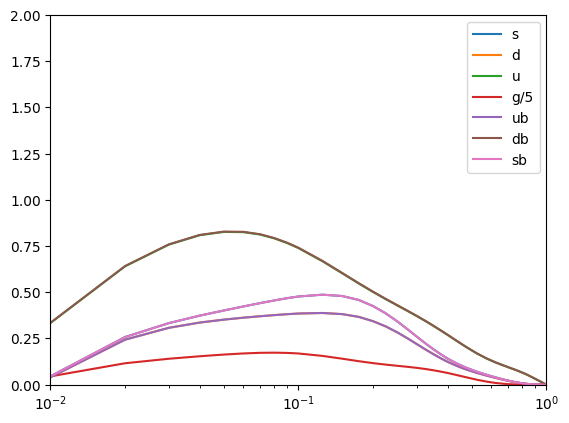

In [18]:
plt.plot(z_array_fortran, s_array_fortran, label="s")
plt.plot(z_array_fortran, d_array_fortran, label="d")
plt.plot(z_array_fortran, u_array_fortran, label="u")
plt.plot(z_array_fortran, g_array_fortran, label="g/5")
plt.plot(z_array_fortran, ub_array_fortran, label="ub")
plt.plot(z_array_fortran, db_array_fortran, label="db")
plt.plot(z_array_fortran, sb_array_fortran, label="sb")

plt.xscale("log")
plt.ylim(0,2)
plt.xlim(10**(-2),1)
plt.legend()